# Churn Customer Prediction

## 1. Problem Definition

The main goal of every company is to maximize profit. In a competitive market, however, many businesses offer similar products or services, which makes it important for companies to understand why customers may choose to leave or stop using their services. Marketing teams use this information to identify customers who are at risk of leaving and to develop alternative strategies, plans, and campaigns to keep them engaged.

This research aims to help readers understand how companies can reduce customer loss. By studying customer behavior and identifying the reasons behind churn, businesses can take action earlier and design better retention strategies. The goal is to show how companies can respond effectively and maintain strong relationships with their customers.

## 2. EDA

In [3]:
import pandas as pd

In this research, we will use a dataset [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) from Kaggle to build and evaluate the churn prediction model.

In [4]:
df = pd.read_csv("data/raw/data.csv")
modified_data = df.copy()

### 2.1 Data Cleaning and Processing

In [5]:
modified_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
for col in modified_data.columns:
    print(modified_data[col].unique()) 

['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
['Female' 'Male']
[0 1]
['Yes' 'No']
['No' 'Yes']
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
['No' 'Yes']
['No phone service' 'No' 'Yes']
['DSL' 'Fiber optic' 'No']
['No' 'Yes' 'No internet service']
['Yes' 'No' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['Month-to-month' 'One year' 'Two year']
['Yes' 'No']
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
[29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']
['No' 'Yes']


As we swee that Total Charge should be numeric instead of string/object

In [7]:
# convert TotalCharges to numeric first (it is currently string/object)
# import numpy as np
# df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
modified_data["TotalCharges"] = pd.to_numeric(modified_data["TotalCharges"], errors='coerce')

# list of numeric columns
numeric_filter = modified_data.select_dtypes(include=["number"]).columns.tolist()
print(numeric_filter)


['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [8]:
for col in modified_data:
    if col not in numeric_filter:
        modified_data[col].str.strip()

In [9]:
# Check duplicate values and missing values
modified_data.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
# show full rows where TotalCharges is missing
df.loc[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [11]:
modified_data.duplicated().sum()
# rows where any column is null
modified_data = modified_data.dropna(subset=["TotalCharges"]).copy()


In [12]:
modified_data.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

We finish clean missing data, duplicate data. Right now, let's visualise our relationship between target variables and each variables

### 2.2 Univariate Analysis

Check imbalance on our target variable.

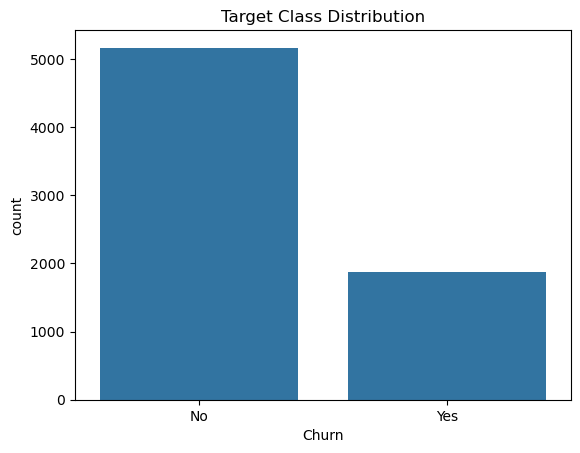

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=modified_data)
plt.title("Target Class Distribution")
plt.show()


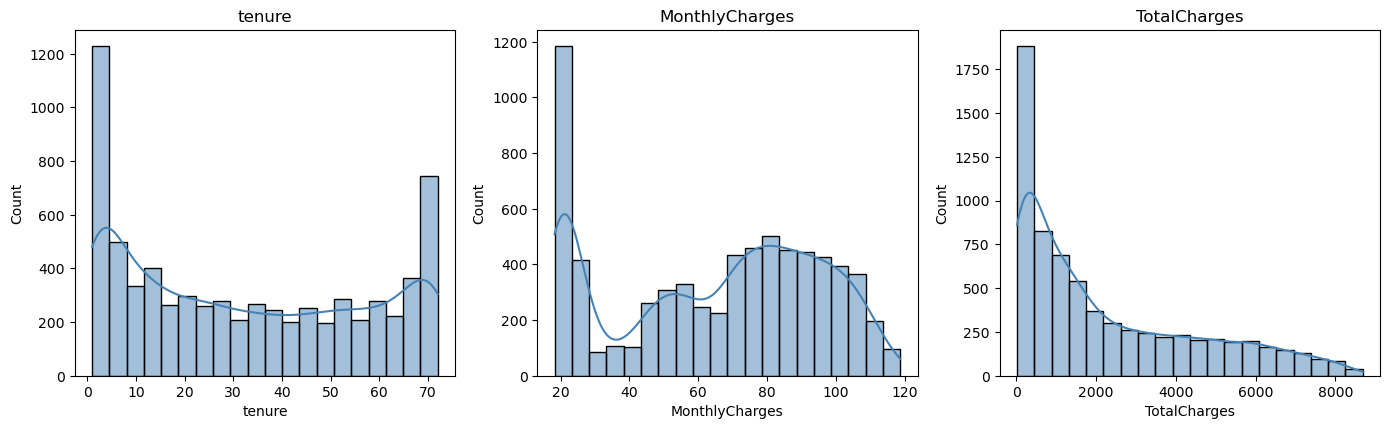

In [21]:
plot_cols = [c for c in numeric_filter if c != "SeniorCitizen"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    sns.histplot(modified_data[col], bins=20, kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(col, fontsize=12)

# hide unused subplots
for j in range(len(plot_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("predictor_histograms.png", dpi=300, bbox_inches="tight")
plt.show()


**Numeric Features:**

* **tenure**
    - U-shaped/polarized distribution: many very new customers (0-5 months) and many long-tenure customers (~70-72 months), with fewer in the middle.
    - Interpretation: customer base is split between recently acquired and very loyal users.
    - Modeling note: likely strong churn signal; churn risk is typically higher in the low-tenure segment.

* **MonthlyCharges**
    - Multi-modal distribution, slightly left-heavy at low values with a broad peak around ~70-95.
    - Interpretation: reflects different service bundles/contract combinations (distinct pricing groups rather than one smooth population).
    - Modeling note: non-linear effects are likely; tree-based models should capture this well.

* **TotalCharges**
    - Strong right skew (long tail): many low totals, fewer very high totals.
    - Interpretation: expected since total bill accumulates over time; heavily influenced by tenure.
    - Modeling note: high collinearity risk with tenure and MonthlyCharges, as roughly TotalCharges ≈ tenure × MonthlyCharges.

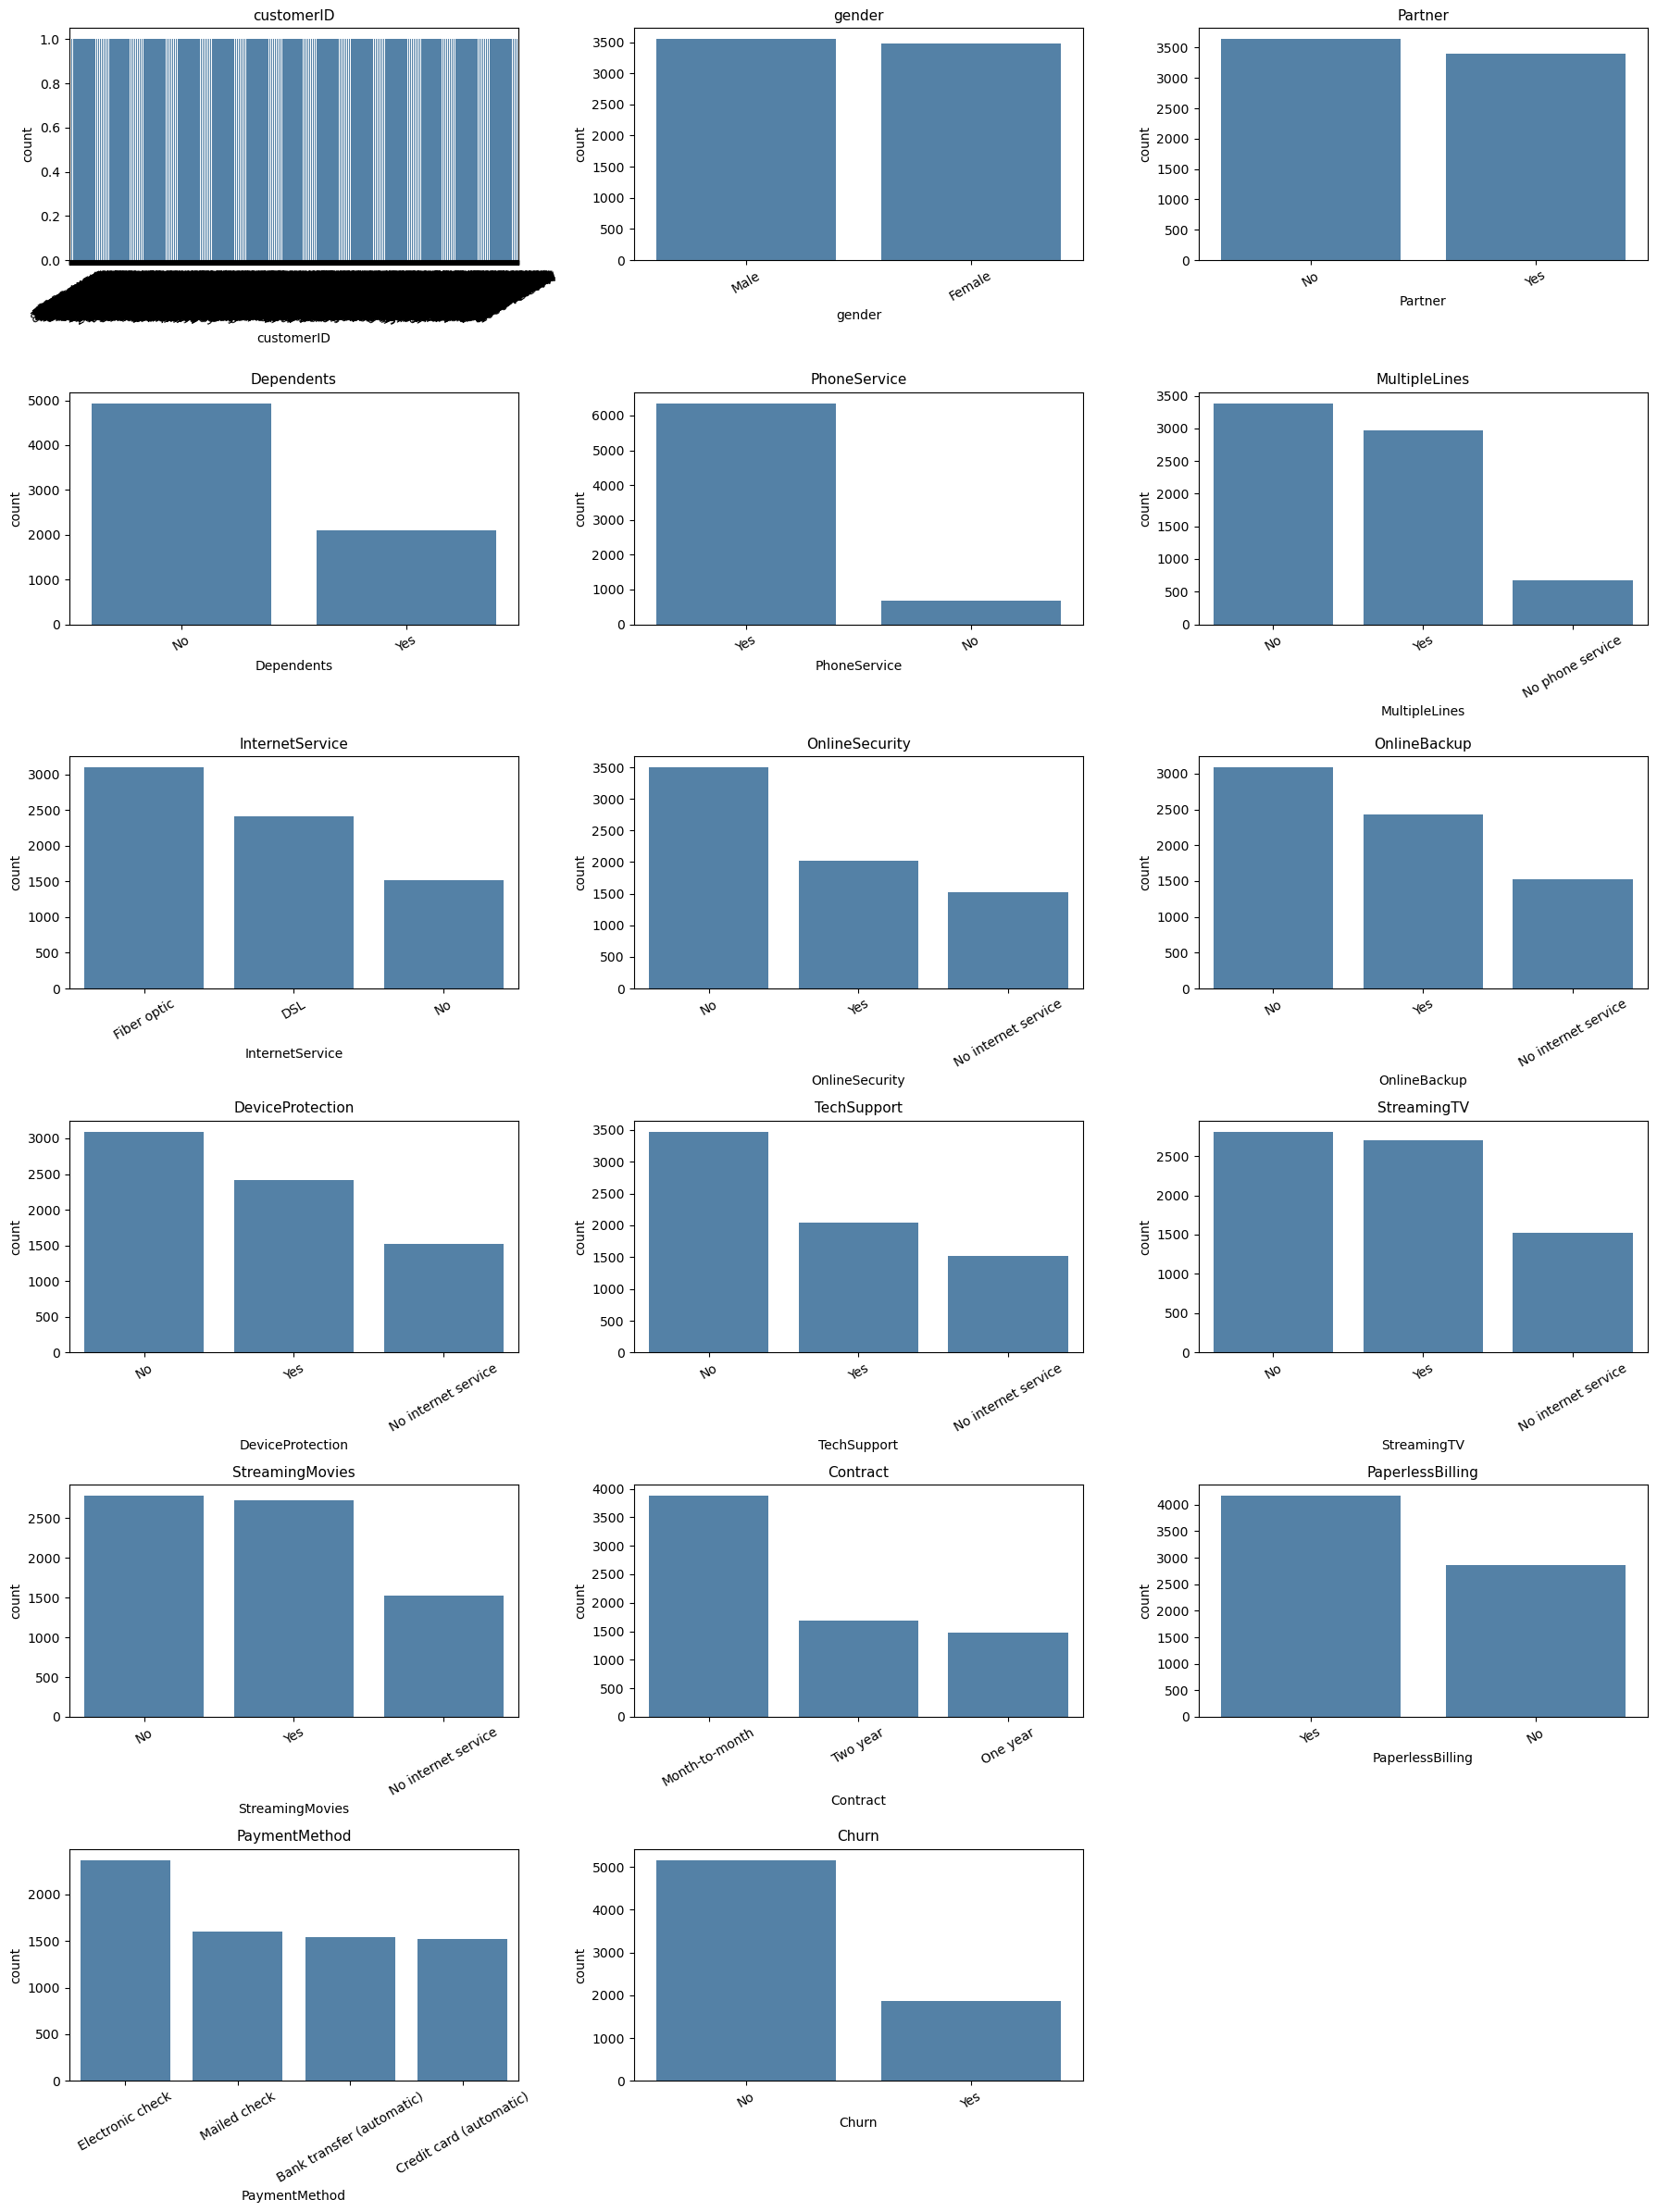

In [22]:
# categorical columns
cat_cols = modified_data.select_dtypes(include=["object", "category"]).columns.tolist()

# optional: include binary numeric columns as categorical
# cat_cols += ["SeniorCitizen"]

n = len(cat_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = modified_data[col].value_counts().index
    sns.countplot(data=modified_data, x=col, order=order, ax=axes[i], color="steelblue")
    axes[i].set_title(col, fontsize=11)
    axes[i].tick_params(axis="x", rotation=30)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("categorical_countplots.png", dpi=300, bbox_inches="tight")
plt.show()


### Key Class Imbalances (Categorical Features)

**Strong imbalance**
- **Churn**: clear skew toward **No** (approximately **73:27** vs **Yes**).
- **PhoneService**: predominantly **Yes**.
- **Dependents**: **No** is noticeably higher than **Yes**.
- **Contract**: **Month-to-month** is dominant; **One year** and **Two year** are much smaller groups.

**Moderate imbalance**
- **PaperlessBilling**: **Yes** is higher than **No**.

**Relatively balanced / mild imbalance**
- **gender**, **Partner**, **MultipleLines**, and most internet add-on features are more evenly distributed, though **No** often remains the largest class.

> **Modeling note:** `customerID` is a unique identifier and should be excluded from predictive features.

## 3. Feature Processing

Before training the models, we choose a **tree-based approach** because it is well-suited for tabular data. Decision trees split data by selecting the most informative features at each step using impurity criteria such as **Gini impurity** or **entropy (information gain)**. This makes them effective for capturing non-linear relationships and feature interactions in churn prediction.